In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models


In [12]:
df = pd.read_csv(
    r"C:\Users\arpit\KUHAR\3.Time_domain_subsamples\KU-HAR_time_domain_subsamples_20750x300.csv",
    header=None
)

data = df.values

signals = data[:, :1800].astype(np.float32)   # 1800 = 300 × 6
labels = data[:, 1800].astype(int)

num_classes = len(np.unique(labels))

print("Signals:", signals.shape)
print("Labels:", labels.shape)
print("Classes:", num_classes)


Signals: (20750, 1800)
Labels: (20750,)
Classes: 18


In [13]:
def normalize_per_sample(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

signals = normalize_per_sample(signals)


In [14]:
X = signals.reshape(-1, 300, 6)
y = labels

print("Model input:", X.shape)


Model input: (20750, 300, 6)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
def augment_sample(X):
    X = X.copy()
    choice = np.random.choice(["noise", "scale", "shift"])

    if choice == "noise":
        X += 0.01 * np.random.randn(*X.shape)

    elif choice == "scale":
        X *= np.random.uniform(0.9, 1.1)

    elif choice == "shift":
        shift = np.random.randint(-5, 5)
        X = np.roll(X, shift, axis=1)

    return X


In [17]:
X_aug = np.array([augment_sample(x) for x in X_train])

X_train_final = np.concatenate([X_train, X_aug], axis=0)
y_train_final = np.concatenate([y_train, y_train], axis=0)

print("After augmentation:", X_train_final.shape)


After augmentation: (33200, 300, 6)


In [18]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: 0.611147927251307, 1: 0.6152249647913424, 2: 0.641322824911142, 3: 0.6176974026940537, 4: 0.5294042607475443, 5: 0.6360153256704981, 6: 0.6540583136327817, 7: 0.8651240358557432, 8: 1.7302480717114863, 9: 2.4016203703703702, 10: 1.1470425649530127, 11: 1.306263770853006, 12: 3.63079615048119, 13: 4.455179817498658, 14: 1.9374416433239963, 15: 1.4454893765238592, 16: 1.4755555555555555, 17: 2.5197328476017002}


In [19]:
def build_model(num_classes):
    model = models.Sequential([

        layers.Conv1D(64, 5, activation='relu', padding='same',
                      input_shape=(300, 6)),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling1D(2),

        layers.LSTM(128, return_sequences=True),
        layers.LSTM(64),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_model(num_classes)
model.summary()


C:\Users\arpit\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 300, 64)             │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 150, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 150, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 75, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 75, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 18)                  │           2,322 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,322 (852.82 KB)

 Trainable params: 218,322 (852.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train_final, y_train_final,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict
)


Epoch 1/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.4517 - loss: 1.6226 - val_accuracy: 0.6895 - val_loss: 0.8857
Epoch 2/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 73s 175ms/step - accuracy: 0.7143 - loss: 0.7956 - val_accuracy: 0.8053 - val_loss: 0.5911
Epoch 3/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 76s 184ms/step - accuracy: 0.8348 - loss: 0.4761 - val_accuracy: 0.8714 - val_loss: 0.3997
Epoch 4/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 77s 186ms/step - accuracy: 0.8709 - loss: 0.3740 - val_accuracy: 0.8660 - val_loss: 0.4096
Epoch 5/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 77s 185ms/step - accuracy: 0.9117 - loss: 0.2608 - val_accuracy: 0.9199 - val_loss: 0.2555
Epoch 6/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 78s 188ms/step - accuracy: 0.9173 - loss: 0.2398 - val_accuracy: 0.9191 - val_loss: 0.2561
Epoch 7/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 80s 192ms/step - accuracy: 0.9353 - loss: 0.1808 - val_accuracy: 0.9185 - val_loss: 0.2680
Epoch 8/25
415/415 ━━━━━━━━━━━━━━━━━━━━ 83s 200ms/step - accuracy: 0.9424 - loss: 0

In [21]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9506 - loss: 0.2169
Test Accuracy: 0.9506024122238159


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models


In [24]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       377
           1       0.92      0.92      0.92       375
           2       0.92      0.89      0.91       359
           3       0.96      0.94      0.95       373
           4       0.99      0.97      0.98       436
           5       0.95      0.96      0.95       363
           6       0.95      0.95      0.95       352
           7       0.92      0.97      0.95       267
           8       0.96      0.96      0.96       133
           9       0.86      1.00      0.93        96
          10       0.93      0.98      0.96       201
          11       0.98      0.98      0.98       176
          12       0.97      1.00      0.98        63
          13       0.93      1.00      0.96        52
          14       0.98      0.97      0.98       119
          15       0.97      0.96      0.97       160
          16  

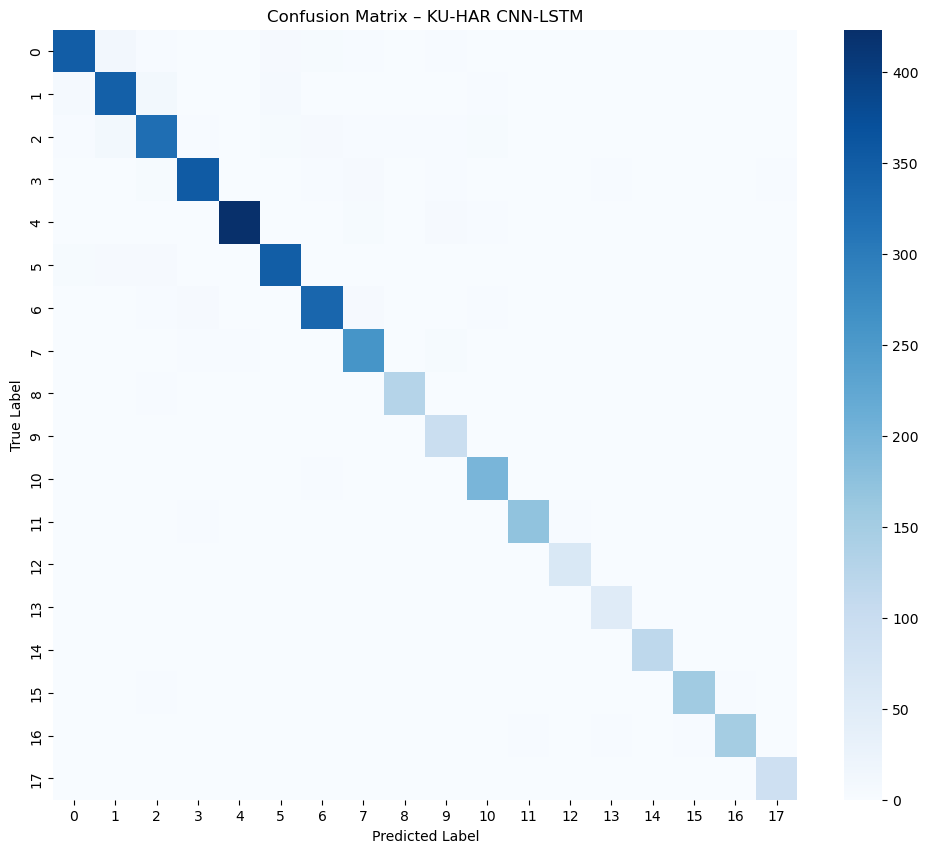

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix – KU-HAR CNN-LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [26]:
model.save("kuhar_cnn_lstm_corrected.h5")
print("Saved kuhar_cnn_lstm_corrected.h5")


Saved kuhar_cnn_lstm_corrected.h5


In [27]:
model = tf.keras.models.load_model("kuhar_cnn_lstm_corrected.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.experimental_enable_resource_variables = True
converter._experimental_lower_tensor_list_ops = False

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_model = converter.convert()

with open("kuhar_cnn_lstm_corrected.tflite", "wb") as f:
    f.write(tflite_model)

print("🎉 TFLite model saved successfully")


INFO:tensorflow:Assets written to: C:\Users\arpit\AppData\Local\Temp\tmpwwtxpnam\assets


INFO:tensorflow:Assets written to: C:\Users\arpit\AppData\Local\Temp\tmpwwtxpnam\assets


Saved artifact at 'C:\Users\arpit\AppData\Local\Temp\tmpwwtxpnam'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 6), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1183558049360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558050128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558050896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558050320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558049168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558051280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558052432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558051664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558052816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1183558053200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  11835580

In [28]:
num_features = df.shape[1] - 1   # last column = label
window_size = num_features // 6  # 6 sensor axes

print("Window size (samples):", window_size)


Window size (samples): 300


In [29]:
step_size = 150
overlap_percent = 100 * (1 - step_size / window_size)

print("Step size:", step_size)
print("Overlap:", overlap_percent, "%")


Step size: 150
Overlap: 50.0 %


In [30]:
sampling_rate = 100  # Hz (documented)
window_duration = window_size / sampling_rate

print("Sampling rate (Hz):", sampling_rate)
print("Window duration (seconds):", window_duration)


Sampling rate (Hz): 100
Window duration (seconds): 3.0


In [31]:
feature_order = [
    "Accelerometer X",
    "Accelerometer Y",
    "Accelerometer Z",
    "Gyroscope X",
    "Gyroscope Y",
    "Gyroscope Z"
]

print("Feature order:")
for i, f in enumerate(feature_order):
    print(f"{i}: {f}")


Feature order:
0: Accelerometer X
1: Accelerometer Y
2: Accelerometer Z
3: Gyroscope X
4: Gyroscope Y
5: Gyroscope Z


In [32]:
signals_raw = df.iloc[:, :1800].values.astype(np.float32)

mean_raw = np.mean(signals_raw)
std_raw = np.std(signals_raw)

print("Mean before normalization:", mean_raw)
print("Std before normalization:", std_raw)


Mean before normalization: 4.1497445
Std before normalization: 3906.263


In [34]:
labels = df.iloc[:, 1800].values.astype(int)
unique_labels = np.unique(labels)

print("Activity labels present:", unique_labels)
print("Number of activities:", len(unique_labels))


Activity labels present: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Number of activities: 18


In [35]:
activity_map = {
    0: "Stand",
    1: "Sit",
    2: "Talk-sit",
    3: "Talk-stand",
    4: "Stand-sit",
    5: "Lay",
    6: "Lay-stand",
    7: "Pick",
    8: "Jump",
    9: "Push-up",
    10: "Sit-up",
    11: "Walk",
    12: "Walk-backward",
    13: "Walk-circle",
    14: "Run",
    15: "Stair-up",
    16: "Stair-down",
    17: "Table-tennis"
}

print("\nActivity Label Mapping:")
for k, v in activity_map.items():
    print(k, "→", v)



Activity Label Mapping:
0 → Stand
1 → Sit
2 → Talk-sit
3 → Talk-stand
4 → Stand-sit
5 → Lay
6 → Lay-stand
7 → Pick
8 → Jump
9 → Push-up
10 → Sit-up
11 → Walk
12 → Walk-backward
13 → Walk-circle
14 → Run
15 → Stair-up
16 → Stair-down
17 → Table-tennis
